# Chicago Nighthawk Project Occupancy Modeling Analysis


For the last 3 years, I have participated in the [Chicago Nighthawk Project](https://www.chicagobirder.org/chicago-nighthawk-project), a citzen science project to monitor the urban population of Common Nighthawks (*Chordeiles minor*). Recently, I attented a talk presented by Timm Haucke from MIT's [Beery Lab](https://beerylab.csail.mit.edu/) on [occupancy modeling](https://armi.usgs.gov/docs/fs2005-3096.pdf) using his sofware [biolith](https://timm.haucke.xyz/biolith/) at the International Conservation Technology Conference in Lima, Peru. Though the terminology was new to me, I immediately realized the Nighthawk Project [protocol](https://static1.squarespace.com/static/580d29af8419c2606f6f60ed/t/66255a82d2a51f2445732852/1713724034744/2024+CONI+Monitoring+Protocol.pdf) made it a perfect fit to be analyzed by occupancy modeling. Specifically, from the perspective of creating an occupancy model, each site was visited 3 times and both positive and negative observations (no nighthawk) were recorded.

This notebook analyses data from the last 3 years of the project as an attempt to better understand some of the concepts of occupancy modeling and become familiar with the biolith software in particular. The primary question I wanted to answer is if these tools validate the intuition that as the number of sites monitored increases, the data gets "better", meaning not only do we have an increased knowledge of where nighthawks are present in Chicago, but that we can trust that we were getting an accurate picture of the population from the survey. Since the survey data included two years of monitoring almost the same number of sites (though different locations) and one year, 2025, that had significantly more sites than the other two, I thought the project would provide an interesting opportunity to test this hypothesis.


## Setup

First, get data and set a few global variables.

In [62]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
DATA_DIR = Path('/content/drive/My Drive/Colab Notebooks/data')

years = ['2023', '2024', '2025']

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Install dependencies.


In [63]:
import importlib.util
import subprocess
import sys

requirements = [
    "biolith",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "contextily",
    "geopandas"
]

missing = []
for pkg in requirements:
    if importlib.util.find_spec(pkg) is None:
        missing.append(pkg)

if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages already installed.")

All required packages already installed.


Import requirements and set a few more globals.

In [64]:
import random

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from biolith.models import occu
from biolith.utils import fit, predict
from biolith.evaluation import lppd

NUM_WARMUP = 500
NUM_SAMPLES = 500
NUM_CHAINS = 3
RANDOM_SEED = 42

sns.set_theme(style="whitegrid")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sigmoid = lambda x: 1.0 / (1.0 + np.exp(-x))

Load and inspect the raw data. Data for each year is stored in a separate csv file.

While there were minor differences between the formats for each year, the information in each is the same. The coluns I am interested in are: latitude and longitude coordinates for a site, unique Location ID, and a column for each observation made.


In [65]:
obs_23_raw = pd.read_csv(DATA_DIR / "2023.csv")
obs_24_raw = pd.read_csv(DATA_DIR / "2024.csv")
obs_25_raw = pd.read_csv(DATA_DIR / "2025.csv")

print("2023 Preview:")
display(obs_23_raw.head(3))

2023 Preview:


,Latitude,Longitude,Location ID,Period 1,Period 2,Period 3,Totals Obsv,Max Count
0,41.83986,-87.64815,McGuane Park,0,-,-,0,0.0
1,41.83451,-87.63504,Armour Sq/ Sox Park,0,-,-,0,0.0
2,41.83470,-87.62500,IIT,0,-,-,0,0.0


In [66]:
print("2024 Preview:")
display(obs_24_raw.head(3))

2024 Preview:


,Latitude,Longitude,Location ID,Period 1 (june 9-15),Period 2 (june 16-22),Period 3 (june 23-29),Total coni Obsv,Max Count,Unnamed: 8
0,41.962615,-87.648956,Chicago Nighthawk Project 4,0,0,0,0.0,0.0,NaN
1,41.951895,-87.642011,Chicago Nighthawk Project Point 2,0,0,0,0.0,0.0,NaN
2,41.956492,-87.648625,Chicago Nighthawk Project Point 3,0,0,0,0.0,0.0,NaN


In [67]:
print("2025 Preview:")
display(obs_25_raw.head(3))

2025 Preview:


,Latitude,Longitude,Location ID,Period 1 (june 9-15),Period 2 (june 16-22),Period 3 (june 23-29),Total coni Obsv,Max Count
0,42.016203,-87.677326,Pottawattomie Park,2,2,1,5,2
1,42.024555,-87.684995,St. Francis Hospital,0,0,0,0,0
2,42.02822,-87.689275,Kaman Park,0,0,0,0,0


##  Clean the data

As with any real-world data, there was a bit of data transformation and cleanup to do. In this case, that involved:
* Standardizing the observation column names (I call them "A", "B", and "C").
* Standardizing lat/long coordinate formats.
* Handling the different ways in which missed observations were entered

Note that missed observations are not the same as negative observiations: a missed observation most likely means the volunteer failed to make or record the site visit for whatever reason.

In [68]:
def convert_to_dd(coord:str) -> float:
  """
  Helper function that takes a given a coordinate string and converts to a float
  for use in numeric lat/long coordinates.

  Converts Data Minutes Seconds format '87*40'33"W' to Decimal Degrees.
  WARNING: other DMS formats not currently handled.
  """
  try:
    return float(coord)
  except ValueError:
    # no need for regexes here b/c I know the format
    deg, tail = coord.split('*')
    mins, tail = tail.split('\'')
    secs, tail = tail.split('"')
    direction = tail[-1]

    dd = float(deg) + float(mins)/60 + float(secs)/3600

    if direction in ["S", "W"]:
        dd = -dd
    return dd

def clean_obs_df(obs_df):
  """
  Cleans and preprocesses the raw observation DataFrame.

  Normalizes column names to 'A', 'B', and 'C' for site visits, drops unnecessary
  columns, and handles invalid data entries (e.g., '-' or 'nan'). It converts
  observation counts to binary (0 or 1 for presence/absence) and converts
  latitude/longitude coordinates to decimal degrees.

  Args:
    obs_df (pd.DataFrame): The raw DataFrame containing observation data,
                           including 'Location ID', 'Latitude', 'Longitude',
                           and period-specific observation columns.

  Returns:
    tuple[pd.DataFrame, pd.DataFrame]: A tuple containing two DataFrames:
      - obs_only_df (pd.DataFrame): A DataFrame with 'Location ID' as index
                                     and binary observation columns ('A', 'B', 'C').
      - obs_geo (pd.DataFrame): A DataFrame similar to obs_only_df but also
                                 including 'Latitude' and 'Longitude' columns.
  """
  col_rename_map = {"Period 1 (june 9-15)": "A",
                    "Period 1": "A",
                    "Period 2 (june 16-22)": "B",
                    "Period 2": "B",
                    "Period 3 (june 23-29)": "C",
                    "Period 3": "C",
                    }
  drop_columns = ['Total coni Obsv', 'Max Count', 'Unnamed: 8', 'Totals Obsv']
  obs_df.rename(columns=col_rename_map, inplace=True)
  obs_df.drop(columns=drop_columns, inplace=True, errors='ignore')

  if obs_df.index.name != 'Location ID':
    obs_df.set_index("Location ID", inplace=True)

  # Identify observation columns
  obs_cols = ['A', 'B', 'C']

  # Process observation columns to convert missing obs values to NaN and then binarize
  for colname in obs_cols:
    # Ensure column is string type for replacement
    obs_df[colname] = obs_df[colname].astype(str)
    obs_df[colname] = obs_df[colname].str.replace('-', str(np.nan), regex=False)\
                                     .str.replace(' ', str(np.nan), regex=False)\
                                     .str.replace('nan', str(np.nan), regex=False)
    # Convert to numeric, coercing any remaining non-numeric (e.g., 'nan' string) to actual np.nan
    obs_df[colname] = pd.to_numeric(obs_df[colname], errors='coerce')
    # Convert to binary (1 for >0, 0 for ==0), leave np.nan as np.nan
    obs_df[colname] = obs_df[colname].apply(lambda x: 1.0 if pd.notna(x) and x > 0 else (0.0 if pd.notna(x) and x == 0 else np.nan))

  obs_only_df = obs_df[obs_cols].copy()

  # Process lat/long columns for obs_geo DataFrame
  obs_geo = obs_df.copy()
  obs_geo['Latitude'] = obs_geo['Latitude'].astype(str).apply(convert_to_dd)
  obs_geo['Longitude'] = obs_geo['Longitude'].astype(str).apply(convert_to_dd)

  return obs_only_df, obs_geo

Run cleanup function and preivew the data


In [69]:
obs_23, obs_geo_23 = clean_obs_df(obs_23_raw)
obs_24, obs_geo_24 = clean_obs_df(obs_24_raw)
obs_25, obs_geo_25 = clean_obs_df(obs_25_raw)

print('2023 Preview:')
display(obs_23.head(3))

2023 Preview:


,A,B,C
Location ID,,,
McGuane Park,0.0,NaN,NaN
Armour Sq/ Sox Park,0.0,NaN,NaN
IIT,0.0,NaN,NaN


In [70]:
print('2024 Preview:')
display(obs_24.head(3))

2024 Preview:


,A,B,C
Location ID,,,
Chicago Nighthawk Project 4,0.0,0.0,0.0
Chicago Nighthawk Project Point 2,0.0,0.0,0.0
Chicago Nighthawk Project Point 3,0.0,0.0,0.0


In [71]:
print('2025 Preview:')
display(obs_25.head(3))

2025 Preview:


,A,B,C
Location ID,,,
Pottawattomie Park,1.0,1.0,1.0
St. Francis Hospital,0.0,0.0,0.0
Kaman Park,0.0,0.0,0.0


In [72]:
print('Show sample of dataframe with geo coords:')
display(obs_geo_23.head(3))

Show sample of dataframe with geo coords:


,Latitude,Longitude,A,B,C
Location ID,,,,,
McGuane Park,41.83986,-87.64815,0.0,NaN,NaN
Armour Sq/ Sox Park,41.83451,-87.63504,0.0,NaN,NaN
IIT,41.83470,-87.62500,0.0,NaN,NaN


We can now get some summmary statistics for each year.

In [73]:
summary_data = []

for year, obs_df in zip([2023, 2024, 2025], [obs_23, obs_24, obs_25]):
    total_sites = obs_df.shape[0]

    # Calculate sites with at least one positive observation (any 1 in 'A', 'B', or 'C')
    sites_with_pos_obs = (obs_df[['A', 'B', 'C']] == 1).any(axis=1).sum()

    summary_data.append({
        'Total Sites': total_sites,
        'Sites Having Positive Observations': sites_with_pos_obs,
        'Total Positive Observations': int(np.nansum(obs_df.values)),
        'Positive Observation Rate':  str(round(np.nansum(obs_df.values) / obs_df.size, 2) * 100) + '%'
    })

summary_df = pd.DataFrame(summary_data, index=years)
display(summary_df)

,Total Sites,Sites Having Positive Observations,Total Positive Observations,Positive Observation Rate
2023,130,42,75,19.0%
2024,135,49,81,20.0%
2025,240,68,124,17.0%


## Show observations on map

Showing the observations on a map illustrates how many more observations were made in the last year. It also shows clustering of sites around parts of the city with especially dense human populations

Note that here we do consider a missed observation equivalent to a negative observation because it is "non-positive".

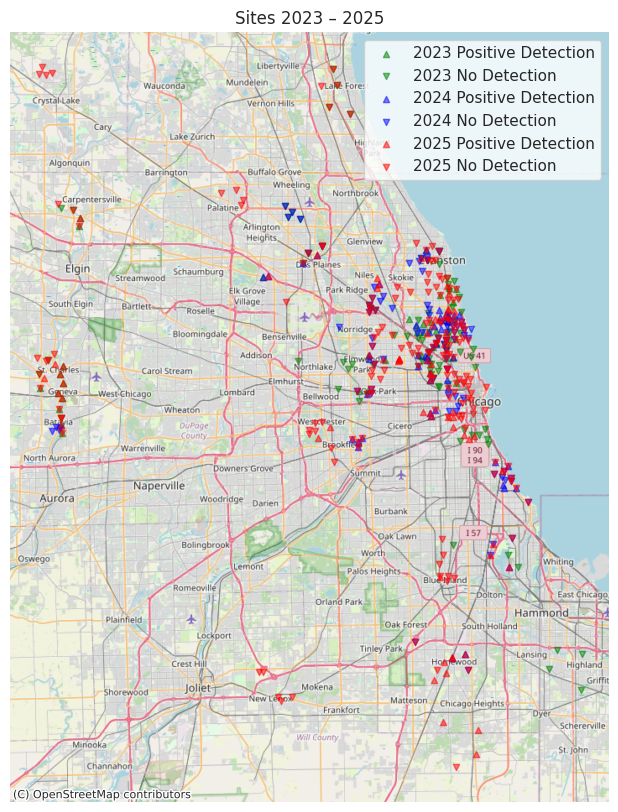

In [74]:
# Bounding box around Chicago
lat_min, lat_max = 41.6, 42.1
lon_min, lon_max = -88.0, -87.4

gdf_2023 = gpd.GeoDataFrame(
    obs_geo_23,
    geometry=gpd.points_from_xy(obs_geo_23['Longitude'], obs_geo_23['Latitude']),
    crs="EPSG:4326"
)
gdf_2024 = gpd.GeoDataFrame(
    obs_geo_24,
    geometry=gpd.points_from_xy(obs_geo_24['Longitude'], obs_geo_24['Latitude']),
    crs="EPSG:4326"
)
gdf_2025 = gpd.GeoDataFrame(
    obs_geo_25,
    geometry=gpd.points_from_xy(obs_geo_25['Longitude'], obs_geo_25['Latitude']),
    crs="EPSG:4326"
)

gdf_2023 = gdf_2023.to_crs(epsg=3857)
gdf_2024 = gdf_2024.to_crs(epsg=3857)
gdf_2025 = gdf_2025.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10,10))

year_colors = {
    "2023": "green",
    "2024": "blue",
    "2025": "red"
}

for year_label, gdf_year in {"2023": gdf_2023, "2024": gdf_2024, "2025": gdf_2025}.items():
    color = year_colors[year_label]
    # Determine positive observations (any 1 in columns A, B, or C)
    positive_obs_mask = (gdf_year['A'] == 1) | (gdf_year['B'] == 1) | (gdf_year['C'] == 1)
    if not gdf_year[positive_obs_mask].empty:
        gdf_year[positive_obs_mask].plot(
            ax=ax, color=color, markersize=20, alpha=0.5, label=f"{year_label} Positive Detection", marker='^'
        )
    if not gdf_year[~positive_obs_mask].empty:
        gdf_year[~positive_obs_mask].plot(
            ax=ax, color=color, markersize=20, alpha=0.5, label=f"{year_label} No Detection", marker='v'
        )

cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)

ax.legend()
ax.set_axis_off()
plt.title("Sites 2023 – 2025")

plt.show()

## Run the biolith occupancy model
Now we'll run the occupancy model for each year and have a look at the results below.


In [75]:
# add output of analysis for all 3 years here
# "minimal" refers to no covariates
minimal_fits = []

obs_dfs = [obs_23, obs_24, obs_25]

# create empty coverate arrays
obs_covs = [
    np.zeros((obs_df.shape[0], obs_df.shape[1], 0), dtype=float)
    for obs_df in obs_dfs
]
dfs_for_fit = zip(years, obs_dfs, obs_covs)
for year, obs_df, obs_covs in dfs_for_fit:
  print('')
  print('--------', year, '--------')
  minimal_fit = fit(
      occu,
      site_covs=pd.DataFrame(index=obs_df.index),
      obs_covs=obs_covs,
      obs=obs_df,
      num_samples=NUM_SAMPLES,
      num_warmup=NUM_WARMUP,
      num_chains=NUM_CHAINS,
      random_seed=RANDOM_SEED,
  )
  minimal_fits.append(minimal_fit)

minimal_fit_23, minimal_fit_24, minimal_fit_25 = minimal_fits


-------- 2023 --------


sample: 100%|██████████| 1000/1000 [00:00<00:00, 1275.28it/s, 1 steps of size 7.90e-01. acc. prob=0.93]



-------- 2024 --------


sample: 100%|██████████| 1000/1000 [00:00<00:00, 1234.38it/s, 1 steps of size 7.12e-01. acc. prob=0.94]



-------- 2025 --------


sample: 100%|██████████| 1000/1000 [00:00<00:00, 1157.73it/s, 3 steps of size 9.67e-01. acc. prob=0.91]


## Explore model results

### Histograms

First I plotted the output of the model as a histogram to see how the occupancy and detection probabilities varied each year.

The model calculates the likelihood of nighthawks being present (occupancy probability) and the likelihood of detecting them (detection probability) by exploring many possibilities based on our data (this process is handled by a Markov Chain Monte Carlo simulation in biolith). The histograms show the range of possible values for these probabilities that the model found. A tall, narrow histogram indicates that the model is more certain about a specific probability, while a wider one shows more uncertainty. These plots summarize the most likely values for site occupancy and detection, and their spread reflects the model's confidence in those estimates. The values, therefore, represent a posterior, or Bayesian, distribution.

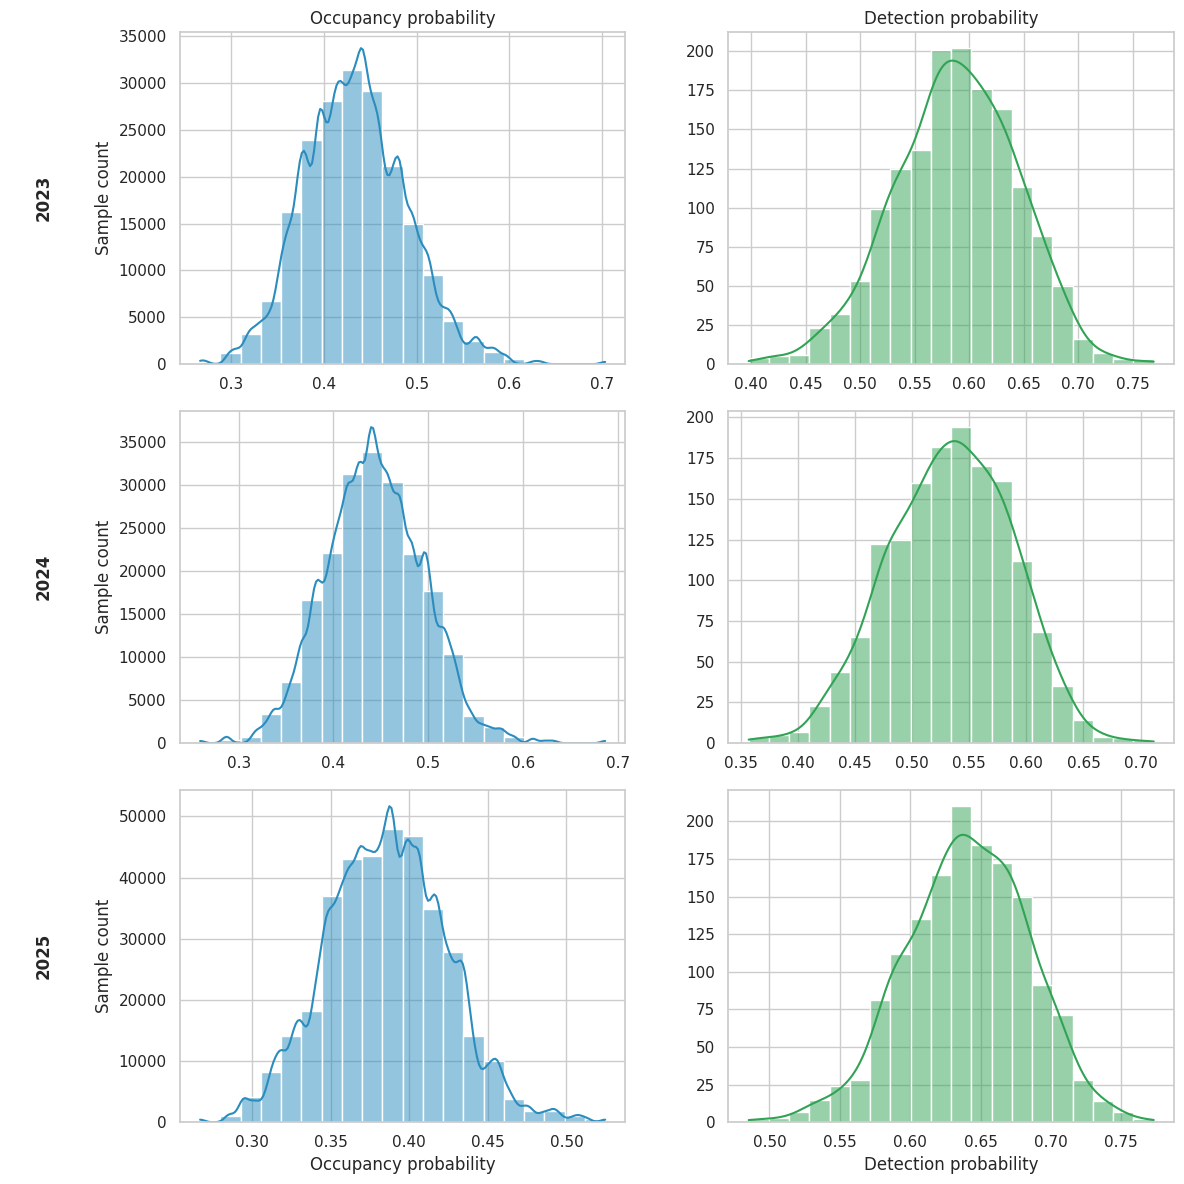

In [76]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(12, 12))

# 3 rows, 3 columns (first column is narrow for labels)
gs = GridSpec(3, 3, figure=fig, width_ratios=[0.15, 1, 1])

row_labels = ["2023", "2024", "2025"]

# Data for plotting
psi_samples = [
    minimal_fit_23.samples["psi"].reshape(-1),
    minimal_fit_24.samples["psi"].reshape(-1),
    minimal_fit_25.samples["psi"].reshape(-1),
]
det_samples = [
    sigmoid(minimal_fit_23.samples["cov_det_0"].reshape(-1)),
    sigmoid(minimal_fit_24.samples["cov_det_0"].reshape(-1)),
    sigmoid(minimal_fit_25.samples["cov_det_0"].reshape(-1)),
]

for r in range(3):
    # Row label axis
    ax_label = fig.add_subplot(gs[r, 0])
    ax_label.axis("off")
    ax_label.text(
        0.5, 0.5,
        row_labels[r],
        rotation=90,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    # Occupancy probability histogram
    ax_psi = fig.add_subplot(gs[r, 1])
    sns.histplot(psi_samples[r], bins=20, kde=True, ax=ax_psi, color="#2b8cbe")
    if r == 0: # Only add title to the first row
        ax_psi.set_title("Occupancy probability")
    if r == 2: # Only add xlabel to the last row
        ax_psi.set_xlabel("Occupancy probability")
    else:
        ax_psi.set_xlabel("") # Remove xlabel for middle rows
    ax_psi.set_ylabel("Sample count")

    # Detection probability histogram
    ax_det = fig.add_subplot(gs[r, 2])
    sns.histplot(det_samples[r], bins=20, kde=True, ax=ax_det, color="#31a354")
    if r == 0: # Only add title to the first row
        ax_det.set_title("Detection probability")
    if r == 2: # Only add xlabel to the last row
        ax_det.set_xlabel("Detection probability")
    else:
        ax_det.set_xlabel("") # Remove xlabel for middle rows
    ax_det.set_ylabel("")

fig.tight_layout()
plt.show()


The histograms of simulation samples do indeed show increasing confidence in the data in the last year:

For 2023 and 2024, the fact that two years of different data and sites, but with a consistent number of sites,  resulted in similar probability distributions showed that there was most likely not a significant ecological change or change in the quality of our sampling.

In 2025, however, we see a noticeable and encouraging change. With a significantly increased number of sites, the histograms, especially for occupancy, become taller and narrower (note the change in axes range).



## Box and whisker plots

While  histograms are a logical way to show a distribution of probabilities, the differences between them can be a little hard to see. The plots below show the same data as box and whisker plots, which make it easier to plot against the number of sites visited as well as visualize the tightness of the probability ranges, which shrink as the model becomes more confident.

First, get some summary values.

In [77]:
n_sites_23 = minimal_fit_23.samples["psi"].shape[1]
n_sites_24 = minimal_fit_24.samples["psi"].shape[1]
n_sites_25 = minimal_fit_25.samples["psi"].shape[1]

n_sites_values = [n_sites_23, n_sites_24, n_sites_25]

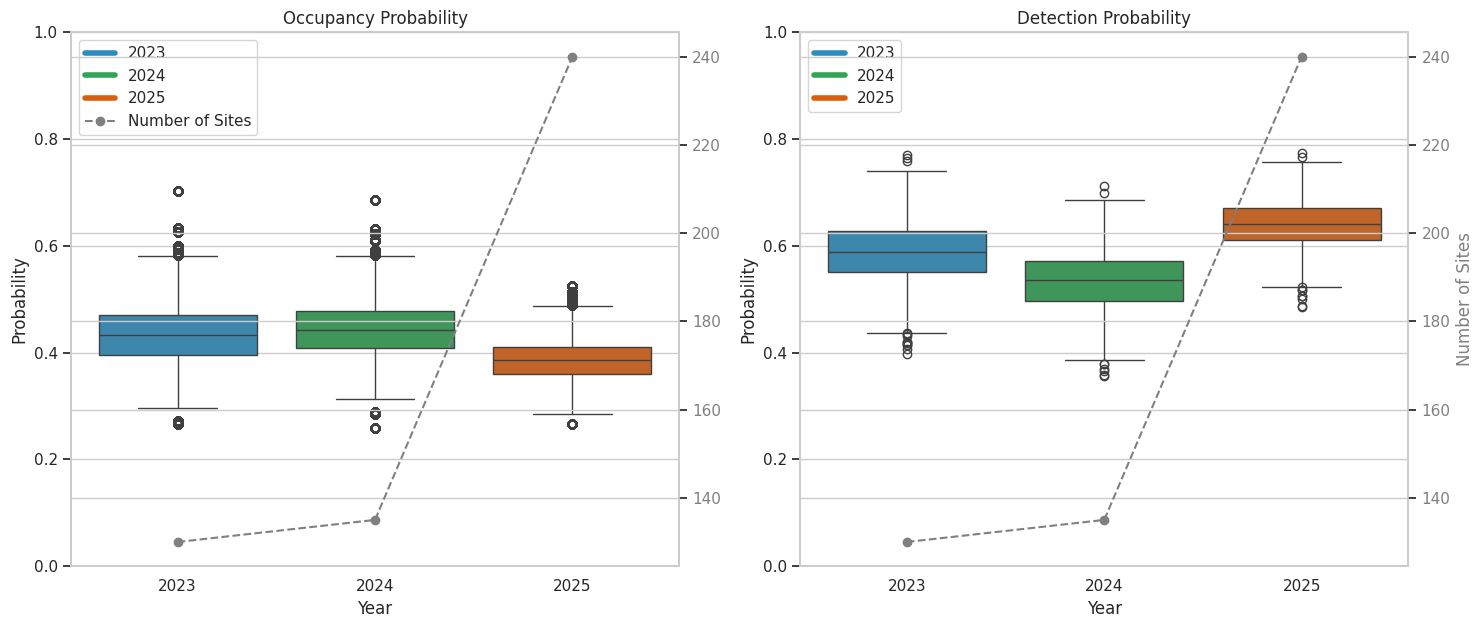

In [78]:
# Prepare data for seaborn boxplots
all_psi_samples = np.concatenate([psi_samples[0], psi_samples[1], psi_samples[2]])
all_det_samples = np.concatenate([det_samples[0], det_samples[1], det_samples[2]])
all_years_psi = ['2023']*len(psi_samples[0]) + ['2024']*len(psi_samples[1]) + ['2025']*len(psi_samples[2])
all_years_det = ['2023']*len(det_samples[0]) + ['2024']*len(det_samples[1]) + ['2025']*len(det_samples[2])

psi_df = pd.DataFrame({'Probability': all_psi_samples, 'Year': all_years_psi})
det_df = pd.DataFrame({'Probability': all_det_samples, 'Year': all_years_det})

colors = {'2023': '#2b8cbe', '2024': '#31a354', '2025': '#d95f0e'}
site_line_color = 'gray'

# Create the figure and two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# --- Occupancy Probability Subplot (Left Column) ---
ax1 = axes[0]
ax1_secondary = ax1.twinx() # Create a secondary y-axis

# Plot box plots for Occupancy Probability
sns.boxplot(x='Year', y='Probability', data=psi_df, ax=ax1,
            palette=colors, showfliers=True, hue='Year',
            legend=False) # Manual legend creation below

# Plot Number of Sites on the secondary y-axis
ax1_secondary.plot(years, n_sites_values, color=site_line_color, linestyle='--', marker='o', label='Number of Sites')

# Set titles and labels for the first subplot
ax1.set_title("Occupancy Probability")
ax1.set_xlabel("Year")
ax1.set_ylabel("Probability")
# ax1_secondary.set_ylabel("Number of Sites", color=site_line_color)
ax1_secondary.tick_params(axis='y', labelcolor=site_line_color) # Set color for secondary y-axis labels
ax1.set_ylim(0, 1) # Probabilities are between 0 and 1

# Create custom legend handles for the box plots for each year
box_legend_handles_1 = [plt.Line2D([0], [0], color=colors[year], lw=4, label=year) for year in years]
# Get the handle for 'Number of Sites' from the secondary axis plot
site_legend_handle_1, site_legend_label_1 = ax1_secondary.get_legend_handles_labels()[0], ax1_secondary.get_legend_handles_labels()[1][0]
# Combine and display legend for ax1
ax1.legend(handles=box_legend_handles_1 + site_legend_handle_1, labels=[h.get_label() for h in box_legend_handles_1] + [site_legend_label_1], loc='upper left')


# --- Detection Probability Subplot (Right Column) ---
ax2 = axes[1]
ax2_secondary = ax2.twinx() # Create a secondary y-axis

# Plot box plots for Detection Probability
sns.boxplot(x='Year',
            y='Probability',
            data=det_df, ax=ax2,
            palette=colors, showfliers=True, hue='Year',
            legend=False) # Manual legend creation below

# Plot Number of Sites on the secondary y-axis (no label here to avoid duplicate legend entry for 'Number of Sites')
ax2_secondary.plot(years, n_sites_values, color=site_line_color, linestyle='--', marker='o')

# Set titles and labels for the second subplot
ax2.set_title("Detection Probability")
ax2.set_xlabel("Year")
# ax2.set_ylabel("Probability")
ax2_secondary.set_ylabel("Number of Sites", color=site_line_color)
ax2_secondary.tick_params(axis='y', labelcolor=site_line_color) # Set color for secondary y-axis labels
ax2.set_ylim(0, 1) # Probabilities are between 0 and 1

# Create custom legend handles for the box plots for each year (only year legends for ax2)
box_legend_handles_2 = [plt.Line2D([0], [0], color=colors[year], lw=4, label=year) for year in years]
ax2.legend(handles=box_legend_handles_2, labels=[h.get_label() for h in box_legend_handles_2], loc='upper left')

# Final layout adjustments
fig.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for the suptitle
plt.show()

The box and whisker plots do indeed show different insights into the data. For one, we can see that the mean value (the center of the boxes) of both occupancy and detection fluctuates, with the overall trend of occupancy decreasing and an increase in detection. This supports the hypothesis that more sites visited leads to better data: although the occupancy rate seems to have decreased over time, the ability to detect occupancy has increased. This also corresponds to the raw stats we calculated from the observations before running the model: the percentage of positive observations did decrease in 2025.

Additionally, the box and whisker plot makes it easier to see that the model has the most confidence in the 2025 data because the range between the 1st and 3rd quartile and the upper and lower whiskers (which represent the minimum and maximum, ignoring outliers) has become more narrow.

Inspecting and charting the values of these boundaries makes the point more clear.


In [79]:
def calculate_boxplot_stats(samples):
    q1 = np.percentile(samples, 25)
    median = np.percentile(samples, 50)
    q3 = np.percentile(samples, 75)
    iqr = q3 - q1

    # Calculate whisker bounds (excluding outliers based on 1.5*IQR rule)
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    lower_whisker = samples[samples >= lower_fence].min()
    upper_whisker = samples[samples <= upper_fence].max()

    return q1, median, q3, lower_whisker, upper_whisker

# Prepare data for display
all_stats = []

for i, year in enumerate(years):
    # Occupancy Probability (psi)
    psi_q1, psi_median, psi_q3, psi_lw, psi_uw = calculate_boxplot_stats(psi_samples[i])
    all_stats.append({
        'Year': year,
        'Parameter': 'psi',
        'Q1': psi_q1,
        'Median': psi_median,
        'Q3': psi_q3,
        'lw': psi_lw,
        'uw': psi_uw,
        'quartile_range': psi_q3 - psi_q1,
        'whisker_range': psi_uw - psi_lw,
        'precision_from_quartile': 1 / (psi_q3 - psi_q1) if (psi_q3 - psi_q1) != 0 else np.inf,
        'precision_from_whisker': 1 / (psi_uw - psi_lw) if (psi_uw - psi_lw) != 0 else np.inf
    })

    # Detection Probability (det)
    det_q1, det_median, det_q3, det_lw, det_uw = calculate_boxplot_stats(det_samples[i])
    all_stats.append({
        'Year': year,
        'Parameter': 'det',
        'Q1': det_q1,
        'Median': det_median,
        'Q3': det_q3,
        'lw': det_lw,
        'uw': det_uw,
        'quartile_range': det_q3 - det_q1,
        'whisker_range': det_uw - det_lw,
        'precision_from_quartile': 1 / (det_q3 - det_q1) if (det_q3 - det_q1) != 0 else np.inf,
        'precision_from_whisker': 1 / (det_uw - det_lw) if (det_uw - det_lw) != 0 else np.inf
    })

stats_df = pd.DataFrame(all_stats)
display(stats_df)

,Year,Parameter,Q1,Median,Q3,lw,uw,quartile_range,whisker_range,precision_from_quartile,precision_from_whisker
0,2023,psi,0.395327,0.432547,0.470045,0.29599938,0.5812821,0.074718,0.2852827,13.383683,3.5052948
1,2023,det,0.551219,0.589369,0.627750,0.436485,0.740412,0.076531,0.303927,13.066632,3.290264
2,2024,psi,0.409019,0.442374,0.478070,0.31393504,0.5813537,0.069052,0.26741868,14.481925,3.7394545
3,2024,det,0.496085,0.535463,0.572052,0.386754,0.685754,0.075967,0.299001,13.163650,3.344474
4,2025,psi,0.359825,0.385866,0.411552,0.28491002,0.48719743,0.051727,0.2022874,19.332321,4.9434614
5,2025,det,0.611933,0.641110,0.670890,0.523907,0.75698,0.058957,0.233073,16.961554,4.290496


## Box and whisker plot summary

The chart below shows the precision identified by the box and whisker plots by taking the inverse of the range of the quartiles and whiskers. This allows us to quantify the "narrowness" of the results in a way that increases or decreases in porportion to model confidence.

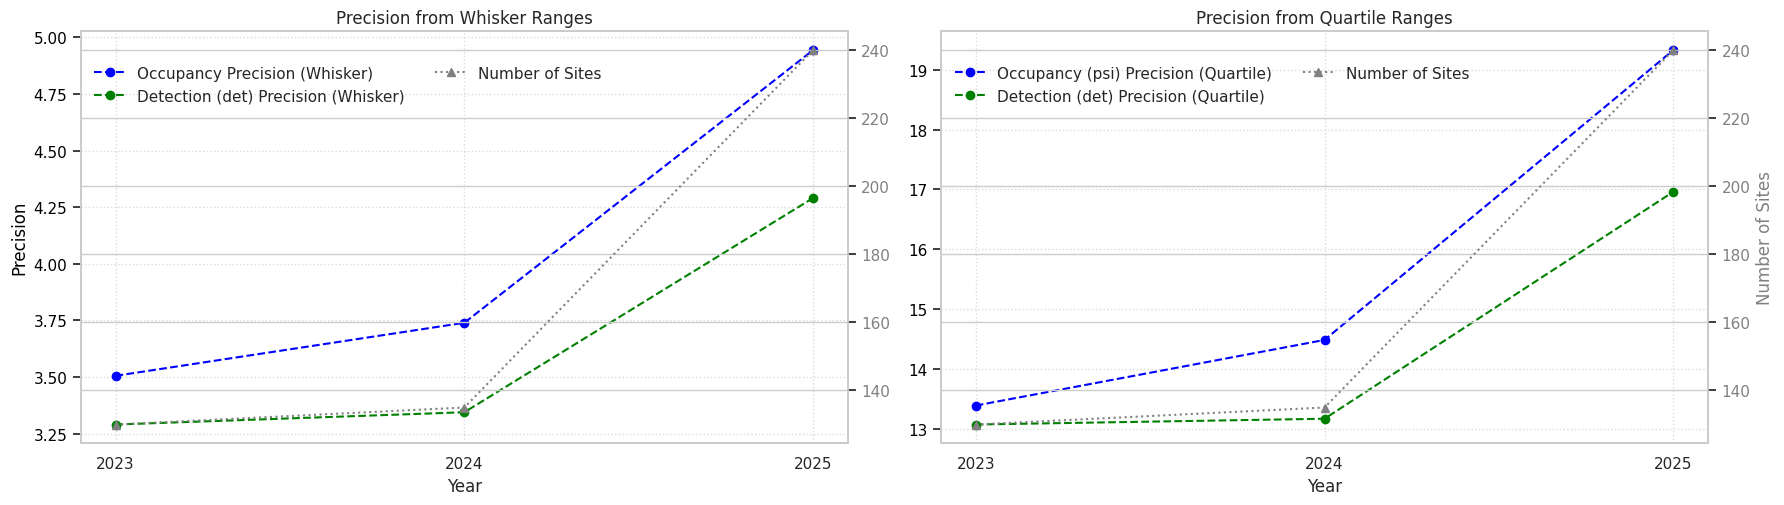

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separate stats for Occupancy and Detection
occupancy_whisker_precision = stats_df[stats_df['Parameter'] == 'psi'].set_index('Year')['precision_from_whisker']
detection_whisker_precision = stats_df[stats_df['Parameter'] == 'det'].set_index('Year')['precision_from_whisker']

occupancy_quartile_precision = stats_df[stats_df['Parameter'] == 'psi'].set_index('Year')['precision_from_quartile']
detection_quartile_precision = stats_df[stats_df['Parameter'] == 'det'].set_index('Year')['precision_from_quartile']

fig, (ax1, ax2_quartile) = plt.subplots(1, 2, figsize=(18, 6))

# --- Left Subplot: Whisker Precision ---
# Plot whisker precision on the primary y-axis (ax1)
ax1.plot(occupancy_whisker_precision.index, occupancy_whisker_precision, marker='o', linestyle='--', color='blue', label='Occupancy Precision (Whisker)')
ax1.plot(detection_whisker_precision.index, detection_whisker_precision, marker='o', linestyle='--', color='green', label='Detection (det) Precision (Whisker)')

ax1.set_title('Precision from Whisker Ranges')
ax1.set_xlabel('Year')
ax1.set_ylabel('Precision', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, linestyle=':', alpha=0.7)

# Create a secondary y-axis for the number of sites on ax1
ax1_twin = ax1.twinx()
ax1_twin.plot(years, n_sites_values, marker='^', linestyle=':', color='gray', label='Number of Sites')
# ax1_twin.set_ylabel('Number of Sites', color='gray')
ax1_twin.tick_params(axis='y', labelcolor='gray')

# Add legend for ax1
handles1, labels1 = ax1.get_legend_handles_labels()
handles1_twin, labels1_twin = ax1_twin.get_legend_handles_labels()
ax1.legend(handles1 + handles1_twin, labels1 + labels1_twin, loc='upper left', bbox_to_anchor=(0, 0.95), ncol=2, frameon=False)

# --- Right Subplot: Quartile Precision ---
# Plot quartile precision on the primary y-axis (ax2_quartile)
ax2_quartile.plot(occupancy_quartile_precision.index, occupancy_quartile_precision, marker='o', linestyle='--', color='blue', label='Occupancy (psi) Precision (Quartile)')
ax2_quartile.plot(detection_quartile_precision.index, detection_quartile_precision, marker='o', linestyle='--', color='green', label='Detection (det) Precision (Quartile)')

ax2_quartile.set_title('Precision from Quartile Ranges')
ax2_quartile.set_xlabel('Year')
# ax2_quartile.set_ylabel('Precision (1 / Range)', color='black')
ax2_quartile.tick_params(axis='y', labelcolor='black')
ax2_quartile.grid(True, linestyle=':', alpha=0.7)

# Create a secondary y-axis for the number of sites on ax2_quartile
ax2_twin = ax2_quartile.twinx()
ax2_twin.plot(years, n_sites_values, marker='^', linestyle=':', color='gray', label='Number of Sites')
ax2_twin.set_ylabel('Number of Sites', color='gray')
ax2_twin.tick_params(axis='y', labelcolor='gray')

# Add legend for ax2_quartile (now including Number of Sites)
handles2_q, labels2_q = ax2_quartile.get_legend_handles_labels()
handles2_twin, labels2_twin = ax2_twin.get_legend_handles_labels()
ax2_quartile.legend(handles2_q + handles2_twin, labels2_q + labels2_twin, loc='upper left', bbox_to_anchor=(0, 0.95), ncol=2, frameon=False)

fig.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent labels/title from overlapping
plt.show()

Now we can really see the increase in model confidence's increase between 2024 and 2025, following the same hockey-stick pattern of the number of sites visited. Based on biolith's analyses of our data, it does seem that more sites visited  indeed leads to a more confident model and "better" data.

## Further exploration

Areas I would like to explore further include:

1.  Covariates - it would be interesting to explore how various site characteristics affect the model's predictions. For example, proximity of sites to busy roads or urban parks. As a characteristic specific to nighthawks is a preference to nest on gravel surfaces, so if data such as locations of buildings with gravel roofs or parking lot surface ares could be found, this may be interesting.
2. Dynamic, or multi-year model - While exact sites vistted year vary year to year, sites common to each year could be identified based on proximity constraints that would allow for a multi-year model to investigate extinction and colonization trends.



